In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv(r"C:\Users\AHILI\OneDrive\Desktop\CollegePlacement.csv")
data

,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,CLG0030,107,6.61,6.28,8,No,8,8,4,No
1,CLG0061,97,5.52,5.37,8,No,7,8,0,No
2,CLG0036,109,5.36,5.83,9,No,3,1,1,No
3,CLG0055,122,5.47,5.75,6,Yes,1,6,1,No
4,CLG0004,96,7.91,7.69,7,No,8,10,2,No
...,...,...,...,...,...,...,...,...,...,...
9995,CLG0021,119,8.41,8.29,4,No,1,8,0,Yes
9996,CLG0098,70,9.25,9.34,7,No,0,7,2,No
9997,CLG0066,89,6.08,6.25,3,Yes,3,9,5,No
9998,CLG0045,107,8.77,8.92,3,No,7,5,1,No


In [3]:
data.head()

,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,CLG0030,107,6.61,6.28,8,No,8,8,4,No
1,CLG0061,97,5.52,5.37,8,No,7,8,0,No
2,CLG0036,109,5.36,5.83,9,No,3,1,1,No
3,CLG0055,122,5.47,5.75,6,Yes,1,6,1,No
4,CLG0004,96,7.91,7.69,7,No,8,10,2,No


In [4]:
data.describe()

,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Extra_Curricular_Score,Communication_Skills,Projects_Completed
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,99.471800,7.535673,7.532379,5.546400,4.970900,5.561800,2.513400
std,15.053101,1.447519,1.470141,2.873477,3.160103,2.900866,1.715959
min,41.000000,5.000000,4.540000,1.000000,0.000000,1.000000,0.000000
25%,89.000000,6.290000,6.290000,3.000000,2.000000,3.000000,1.000000
50%,99.000000,7.560000,7.550000,6.000000,5.000000,6.000000,3.000000
75%,110.000000,8.790000,8.770000,8.000000,8.000000,8.000000,4.000000
max,158.000000,10.000000,10.460000,10.000000,10.000000,10.000000,5.000000


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   College_ID              10000 non-null  object 
 1   IQ                      10000 non-null  int64  
 2   Prev_Sem_Result         10000 non-null  float64
 3   CGPA                    10000 non-null  float64
 4   Academic_Performance    10000 non-null  int64  
 5   Internship_Experience   10000 non-null  object 
 6   Extra_Curricular_Score  10000 non-null  int64  
 7   Communication_Skills    10000 non-null  int64  
 8   Projects_Completed      10000 non-null  int64  
 9   Placement               10000 non-null  object 
dtypes: float64(2), int64(5), object(3)
memory usage: 781.4+ KB


In [6]:
from sklearn.preprocessing import LabelEncoder
label = LabelEncoder()
data['Internship_Experience'] = label.fit_transform(data['Internship_Experience'])
data['Placement'] = label.fit_transform(data['Placement'])

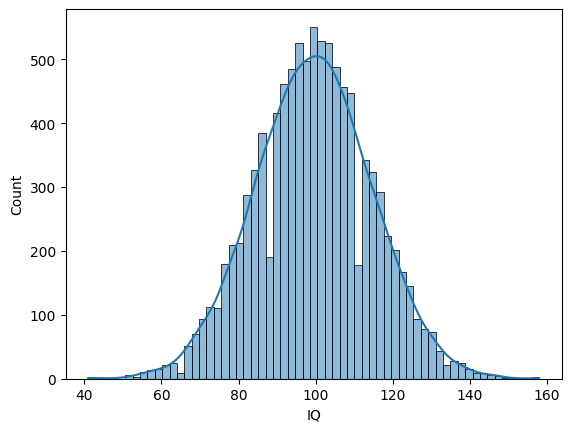

In [7]:
sns.histplot(data['IQ'], kde = True)
plt.show()

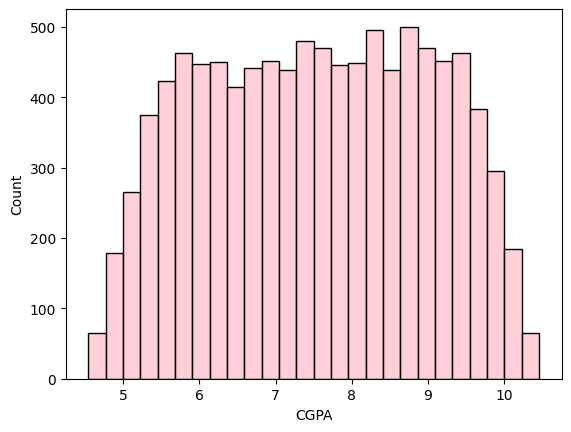

In [8]:
sns.histplot(data['CGPA'], kde = False, color = 'pink')
plt.show()

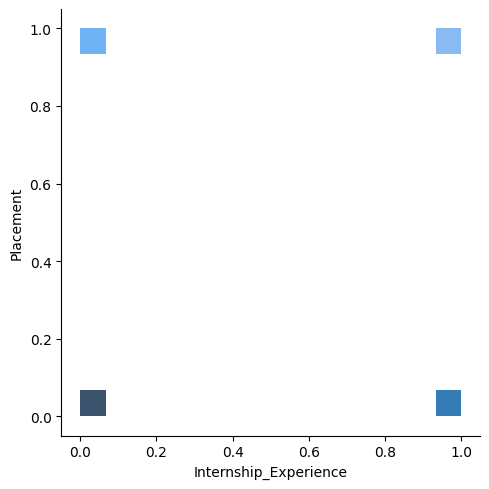

In [9]:
sns.displot(x = 'Internship_Experience', y = 'Placement', data = data)
plt.show()

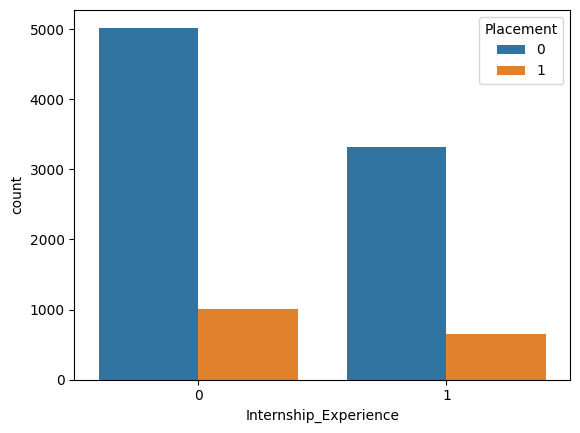

In [10]:
sns.countplot(x ='Internship_Experience', hue = 'Placement', data = data)
plt.show()

In [11]:
X = data.drop(columns = ['College_ID', 'Placement'])
y = data['Placement']

In [12]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [13]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Accuracy: 0.9035
Precision: 0.752851711026616
Recall Score: 0.6073619631901841
F1 Score: 0.6723259762308998


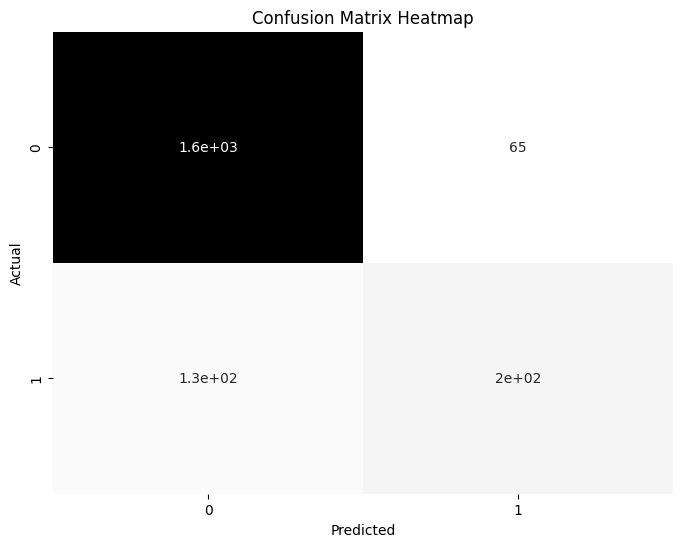

In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall Score:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))

conf_matrix = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot= True, cmap= 'Greys', cbar= False)
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


Accuracy(random forest):  1.0
Precision: 1.0
Recall Score: 1.0
F1 Score: 1.0


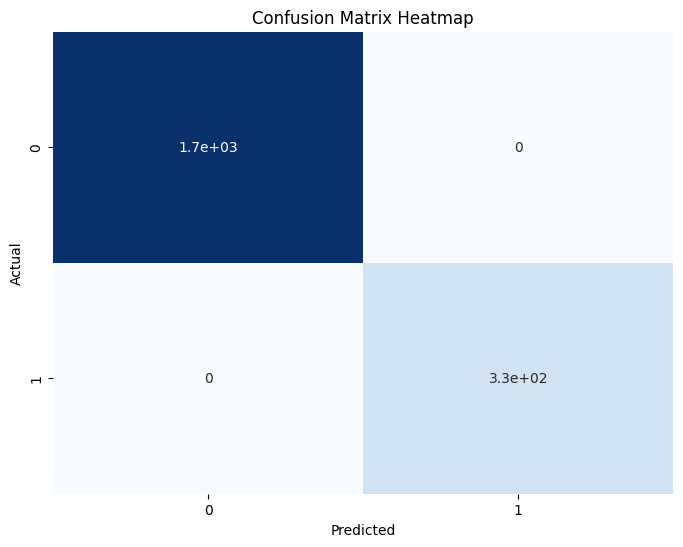

In [26]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state= 42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Accuracy(random forest): ", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall Score:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

conf_matrix = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot= True, cmap= 'Blues', cbar= False)
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

XGBoost Accuracy: 1.0
Precision: 1.0
Recall Score: 1.0
F1 Score: 1.0


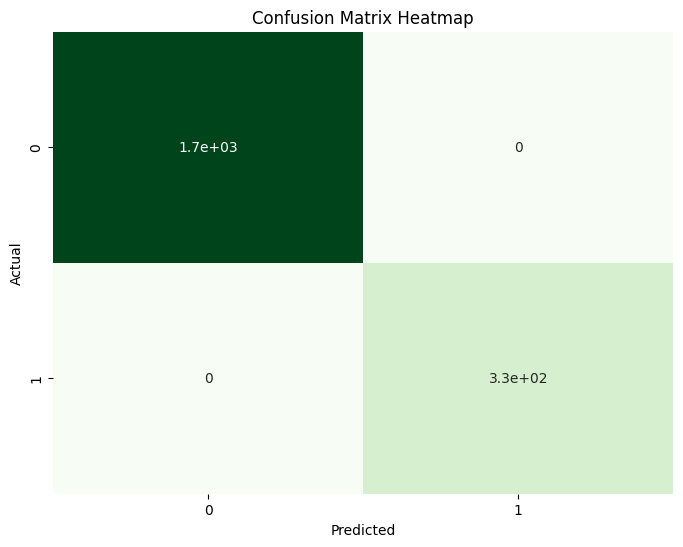

In [41]:
from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall Score:", recall_score(y_test, y_pred_xgb))
print("F1 Score:", f1_score(y_test, y_pred_xgb))

conf_matrix = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot= True, cmap= 'Greens', cbar= False)
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [22]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [100, 200],
    'max_depth':[3, 5, 7]
}
grid = GridSearchCV(RandomForestClassifier(), param_grid, cv = 3, scoring =  'accuracy')
grid.fit(X_train, y_train)

print("Best Parameters found:", grid.best_params_)
print("Best cross validation score:", grid.best_score_)

Best Parameters found: {'max_depth': 7, 'n_estimators': 100}
Best cross validation score: 0.9993750781152356


In [ ]:
#comparing all models
results = {
    "Logistic Regression": [
        accuracy_score(y_test, y_pred_lr), 
        precision_score(y_test, y_pred_lr), 
        recall_score(y_test, y_pred_lr), 
        f1_score(y_test, y_pred_lr)
    ],
    "Random Forest Classifier": [
        accuracy_score(y_test, y_pred_rf), 
        precision_score(y_test, y_pred_rf), 
        recall_score(y_test, y_pred_rf), 
        f1_score(y_test, y_pred_rf)
    ],
    "XGBoost Classifier":[
        accuracy_score(y_test, y_pred_xgb), 
        precision_score(y_test, y_pred_xgb), 
        recall_score(y_test, y_pred_xgb), 
        f1_score(y_test, y_pred_xgb)
    ]
}
data_results = pd.DataFrame(
    results,  
).T  

data_results.columns = ["Accuracy", "Precision", "Recall", "F1 Score"]

print(data_results)

                          Accuracy  Precision    Recall  F1 Score
Logistic Regression         0.9035   0.752852  0.607362  0.672326
Random Forest Classifier    1.0000   1.000000  1.000000  1.000000
XGBoost Classifier          1.0000   1.000000  1.000000  1.000000
